# 1. Introduction


- Agriculture is increasingly adopting data-driven approaches to improve productivity and resource efficiency. Selecting the right crop for a given set of soil and environmental conditions is a critical decision that directly impacts yield and sustainability

- This project focuses on building a machine learning model that recommends the most suitable crop based on key factors such as:
1. soil nutrients (Nitrogen, Phosphorous, Potassium)
2. temperature
3. humidity
4. pH
5. rainfall
- The problem is formulated as a multi-class classification task where each class represents a specific crop type.

> The objective is to develop a reliable and interpretable model that can assist in crop selection. The workflow includes data exploration, preprocessing, model building using a pipeline, evaluation, and interpretation using feature importance and SHAP analysis. The final model is exported for integration into a web application.


# 2. Dataset Overview

- The dataset used in this project contains information about soil composition and environmental conditions, along with the corresponding crop that is best suited for those conditions. It is designed for a multi-class classification task with 22 different crop types.

Each record consists of the following features:

* **N**: Nitrogen content in the soil
* **P**: Phosphorous content in the soil
* **K**: Potassium content in the soil
* **temperature**: Temperature in degrees Celsius
* **humidity**: Relative humidity (%)
* **ph**: Soil pH value
* **rainfall**: Rainfall in millimeters

- The target variable:
* **label**: Crop type (e.g., rice, maize, cotton, etc.)
The dataset is clean, with no missing values, and contains a balanced distribution across multiple crop categories. This makes it suitable for training and evaluating classification models without requiring extensive data cleaning.
- To download the Dataset : [kaggle](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset/data)

# 3. Setup

- We will import important libraries that we gonna need to make end to end prediction pipeline.
- In case we need any other ; we will come back and add it here.
- This will help us to get the idea about all tools we used at one place, Instead of getting scattered over whole notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [93]:
import pickle

# 4. Data Loading

In [6]:
df = pd.read_csv("../data/Crop_recommendation.csv")

In [7]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# 5. Basic Data Inspection

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [9]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [10]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [12]:
df["label"].nunique()

22

In [11]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

---
- we can see that from .info() and .desc..() , we can change the datatype for efficent memory use.
- As for N,P,K the mmax value is still less than 255 which can be easily handle with int8 rather than of int64.
- same goes for float64 -> float32
- and for objects -> category

In [13]:
df['N'] = df['N'].astype('uint8')
df['P'] = df['P'].astype('uint8')
df['K'] = df['K'].astype('uint8')

In [14]:
df[['temperature', 'humidity', 'ph', 'rainfall']] = df[['temperature', 'humidity', 'ph', 'rainfall']].astype('float32')

In [15]:
df['label'] = df['label'].astype('category')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   N            2200 non-null   uint8   
 1   P            2200 non-null   uint8   
 2   K            2200 non-null   uint8   
 3   temperature  2200 non-null   float32 
 4   humidity     2200 non-null   float32 
 5   ph           2200 non-null   float32 
 6   rainfall     2200 non-null   float32 
 7   label        2200 non-null   category
dtypes: category(1), float32(4), uint8(3)
memory usage: 43.8 KB


> Result is here, Before it was taking 137 KB and now 43KB, size reduced by factor of more than 2.

In [17]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616243,71.481781,6.469480,103.463654
std,36.917334,32.985883,50.647931,5.063749,22.263811,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258039,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769374,60.261954,5.971693,64.551685
50%,37.000000,51.000000,32.000000,25.598693,80.473145,6.425045,94.867626
75%,84.250000,68.000000,49.000000,28.561655,89.948772,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675491,99.981873,9.935091,298.560120


# 6. Exploratory Data Analysis (EDA)

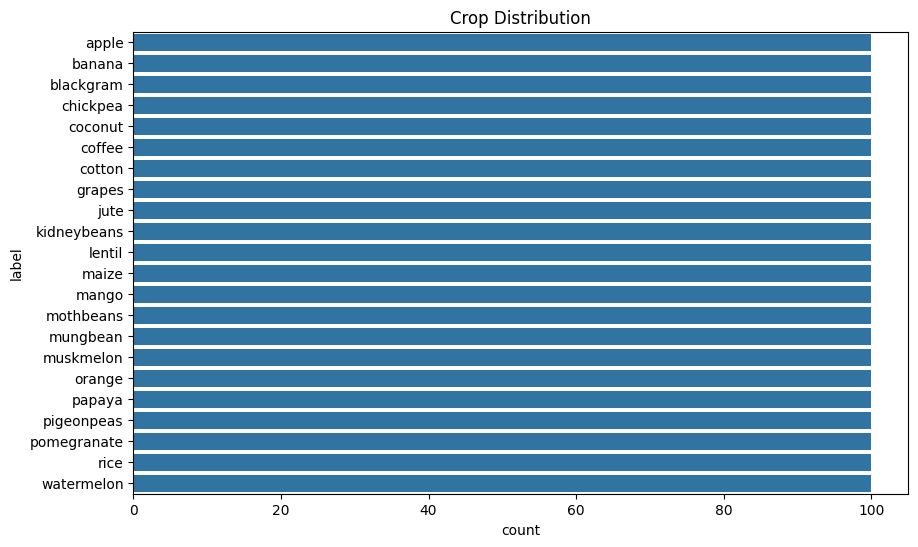

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(y="label", data=df, order=df["label"].value_counts().index)
plt.title("Crop Distribution")
plt.show()

- The table shows the frequency of each crop label in the dataset
- All classes have an equal number of instances (100)
- confirming that the dataset is balanced and suitable for unbiased machine learning modeling
- Equal representation

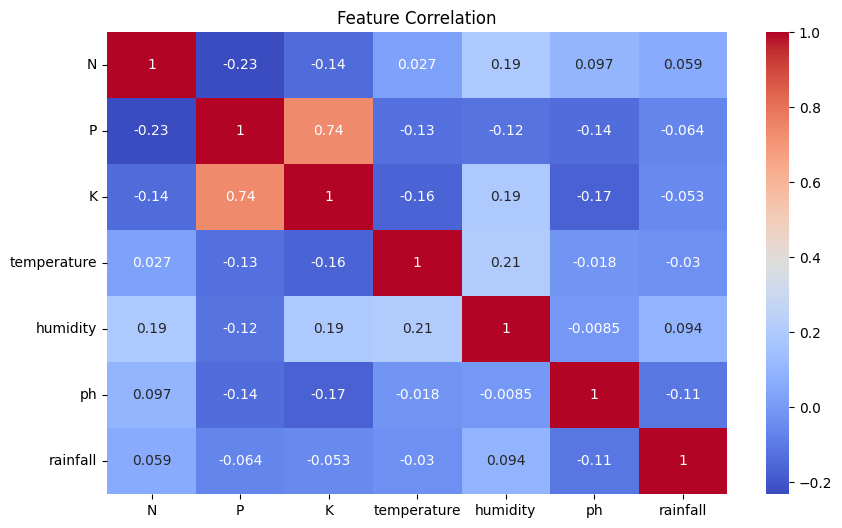

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop("label", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

- The heatmap illustrates the correlation between soil nutrients and environmental factors
- most variables exhibit low correlation values, suggesting that the features are largely independent. However phosphorus (P) and potassium (K) show a strong positive correlation (0.74)

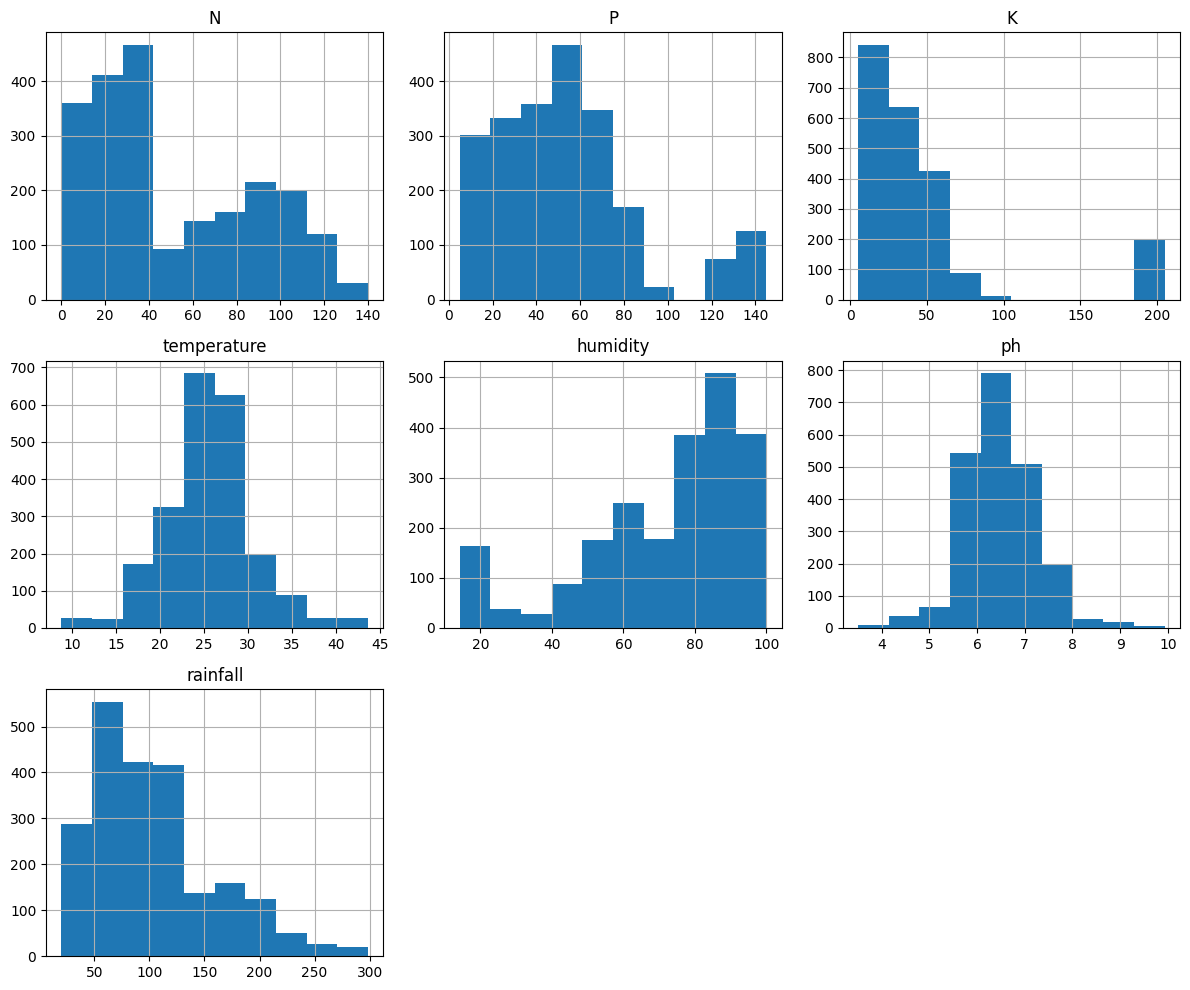

In [20]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

- The histogram analysis reveals that temperature and pH exhibit near-normal distributions, making them well-suited for many machine learning models - - In contrast rainfall and potassium (K) are positively skewed, indicating the presence of higher-value outliers
- Nitrogen (N) and phosphorus (P) show moderately spread distributions
- humidity is skewed toward higher values

# 7. Feature & Target Definition

- Now lets seprate the labels and features i.e Input for our later part of this notebook.
- The model selection and prediction.

In [21]:
# features
X = df.drop("label", axis=1)

In [22]:
# lables(target)
y = df["label"]

In [23]:
X.shape

(2200, 7)

In [24]:
y.shape

(2200,)

In [25]:
X[:5]

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002747,6.502985,202.935532
1,85,58,41,21.770462,80.319641,7.038096,226.655533
2,60,55,44,23.004459,82.320763,7.840207,263.964233
3,74,35,40,26.491096,80.158363,6.980401,242.864029
4,78,42,42,20.130175,81.604874,7.628473,262.717346


In [28]:
y.value_counts()

label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64

# Data Preprocessing

- So, far we Loaded the data then took a few insights.
- Even converted the data types for better speed.
- But for models we need to process our Data.
- for example:
- The labels are in text form.
- Model needs number. Hence we gonna encode it using label encoder
- Then we have to scale all the inputs as they have evry different scales right now
- For this we gonna use standardscaler() via ColumnTransformer.

In [29]:
le = LabelEncoder()

In [30]:
y_encoded = le.fit_transform(y)

In [31]:
y_encoded

array([20, 20, 20, ...,  5,  5,  5], shape=(2200,))

In [32]:
y_encoded[:5]

array([20, 20, 20, 20, 20])

In [33]:
numeric_features = X.columns

In [34]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric_features)])

In [35]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

# 9. Train-Test Split

- We gonna Split our dataset into 2 parts i.e testing and training part.

In [37]:
X_train, X_test, y_train, y_test =train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [39]:
X_train.shape

(1760, 7)

In [40]:
X_test.shape

(440, 7)

In [41]:
y_train.shape

(1760,)

In [42]:
y_test.shape

(440,)

# 10. Model Building (Pipeline)

- Now lets build our model
- 1st we will look for simple model then we will look for complex model, if it imporves the model or not.

In [45]:
pipeline_logistic = Pipeline(steps=[ ("preprocessor", preprocessor), ("model_logistic_r", LogisticRegression(max_iter=5000))])

In [49]:
pipeline_decision = Pipeline(steps=[("preprocessor", preprocessor),("model_random", DecisionTreeClassifier(random_state=42))])

In [50]:
pipeline_random = Pipeline(steps=[("preprocessor", preprocessor),("model_random", RandomForestClassifier(random_state=42))])

# 11. Model Training

In [48]:
pipeline_logistic.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model_logistic_r', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [51]:
pipeline_decision.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model_random', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [52]:
pipeline_random.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model_random', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

# 12. Model Evaluation

In [57]:
models = {
    "Logistic Regression": pipeline_logistic,
    "Decision Tree": pipeline_decision,
    "Random Forest": pipeline_random}

In [58]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.90      0.95      0.93        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.83      0.87      0.85        23
           9       0.95      0.95      0.95        20
          10       0.85      1.00      0.92        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
      

# 13. Cross Validation

In [59]:
for name, model in models.items():
    scores = cross_val_score(model, X, y_encoded, cv=10)
    print(f"{name} CV Score: {scores.mean():.4f}")

Logistic Regression CV Score: 0.9727
Decision Tree CV Score: 0.9905
Random Forest CV Score: 0.9941


> Random Forest achieved the highest cross-validation score (~99.41%), indicating strong generalization. Compared to Decision Tree, it provides better stability by reducing overfitting through ensemble learning. Logistic Regression performed slightly lower due to its linear assumptions

# 14. Feature Importance Analysis

In [62]:
model = pipeline_random.named_steps["model_random"]

In [63]:
imp = model.feature_importances_

In [64]:
imp

array([0.1088589 , 0.1436222 , 0.18122202, 0.07568153, 0.2112786 ,
       0.05230082, 0.22703593])

In [65]:
feature_df = pd.DataFrame({"Feature": X.columns,"Importance": imp}).sort_values(by="Importance", ascending=False)

In [66]:
feature_df

,Feature,Importance
6,rainfall,0.227036
4,humidity,0.211279
2,K,0.181222
1,P,0.143622
0,N,0.108859
3,temperature,0.075682
5,ph,0.052301


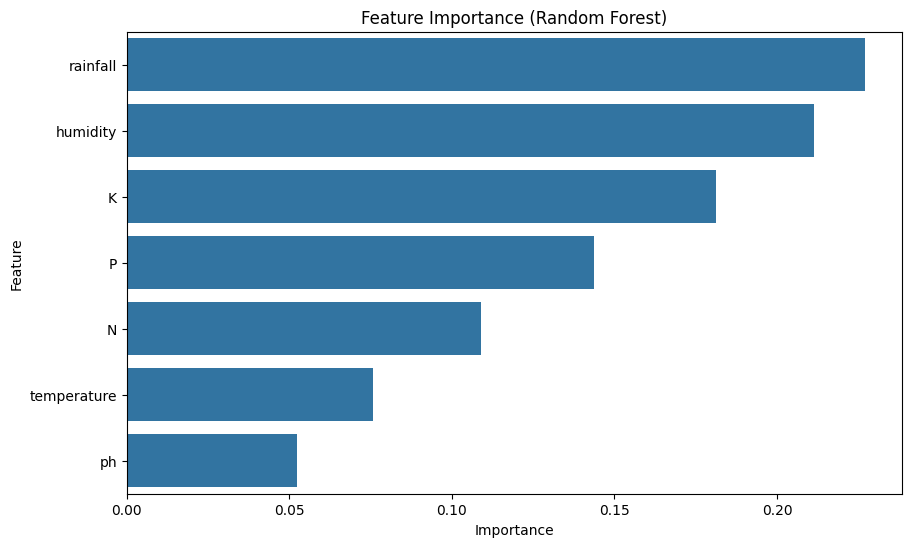

In [67]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_df)
plt.title("Feature Importance (Random Forest)")
plt.show()

> Rainfall, humidity, and potassium are among the most influential features in crop prediction, indicating that both environmental and soil conditions play a critical role

# 15. Model Export

In [95]:
with open("../model/model.pkl", "wb") as f:
    pickle.dump(pipeline_random, f)

In [97]:
with open("../model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

## 16. Model Reload & Test

In [98]:
with open("../model/model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [99]:
with open("../model/label_encoder.pkl", "rb") as f:
    loaded_le = pickle.load(f)

In [100]:
sample = X.iloc[0:1]

In [102]:
sample

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002747,6.502985,202.935532


In [101]:
pred = loaded_model.predict(sample)[0]

In [103]:
pred

np.int64(20)

In [104]:
crop = loaded_le.inverse_transform([pred])[0]

In [105]:
crop

'rice'

In [106]:
y[0]

'rice'

# 18. Conclusion

- In this project, a machine learning pipeline was developed to recommend crops based on soil and environmental conditions. Multiple models were evaluated, including Logistic Regression, Decision Tree, and Random Forest
- Random Forest achieved the highest performance with strong cross-validation accuracy, making it the final selected model. Feature importance analysis showed that rainfall, humidity, and soil nutrients play a significant role in crop prediction.
- The trained model was exported and validated for deployment, enabling integration into a web application for real-time crop recommendations.

***